In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
sns.set_palette('husl')

COUNTRY = 'Kenya'
DATA_PATH = '../data/kenya.csv'
CLEAN_PATH = '../data/kenya_clean.csv'
print('Setup complete.')

Setup complete.


In [2]:
# Load CSV — skip NASA POWER comment header rows
df = pd.read_csv(DATA_PATH, comment='-', na_values=['-999', -999])
df['Country'] = COUNTRY

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (4108, 13)
Columns: ['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Country']


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya


In [3]:
# Convert YEAR + DOY to proper datetime
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month
df = df.sort_values('Date').reset_index(drop=True)

print(f'Date range: {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Total days: {len(df)}')
df[['Date', 'YEAR', 'DOY', 'Month', 'T2M', 'PRECTOTCORR']].head(10)

Date range: 2015-01-01 → 2026-03-31
Total days: 4108


,Date,YEAR,DOY,Month,T2M,PRECTOTCORR
0,2015-01-01,2015,1,1,19.56,0.00
1,2015-01-02,2015,2,1,19.63,0.00
2,2015-01-03,2015,3,1,20.40,0.00
3,2015-01-04,2015,4,1,21.33,3.49
4,2015-01-05,2015,5,1,20.41,1.79
5,2015-01-06,2015,6,1,20.89,0.01
6,2015-01-07,2015,7,1,21.16,0.06
7,2015-01-08,2015,8,1,21.25,0.01
8,2015-01-09,2015,9,1,21.64,0.00
9,2015-01-10,2015,10,1,22.14,0.08


## 2. Summary Statistics & Missing-Value Report

In [4]:
# Replace -999 sentinel values with NaN
numeric_cols = df.select_dtypes(include=[np.number]).columns
sentinel_count = (df[numeric_cols] == -999).sum().sum()
df[numeric_cols] = df[numeric_cols].replace(-999, np.nan)
print(f'Replaced {sentinel_count} sentinel -999 values with NaN')

Replaced 0 sentinel -999 values with NaN


In [5]:
# Duplicate check
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')
if dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Dropped {dupes} duplicates.')

Duplicate rows: 0


In [6]:
# Summary statistics
df.describe().round(2)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Month
count,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00
mean,2020.13,180.12,20.43,27.84,14.67,13.17,1.47,65.85,3.06,4.38,83.72,11.05,6.42
std,3.25,106.29,1.44,2.36,1.42,2.61,3.18,9.93,0.85,0.99,0.13,1.61,3.48
min,2015.00,1.00,15.26,18.88,8.97,4.11,0.00,28.42,0.61,1.16,83.31,4.78,1.00
25%,2017.00,86.00,19.46,26.30,13.70,11.47,0.10,58.68,2.42,3.67,83.63,9.88,3.00
50%,2020.00,179.00,20.36,27.88,14.75,13.26,0.38,66.22,3.14,4.43,83.72,11.00,6.00
75%,2023.00,272.00,21.40,29.52,15.75,15.05,1.36,73.28,3.72,5.09,83.81,12.35,9.00
max,2026.00,366.00,25.40,34.27,18.75,20.12,51.65,91.07,5.28,7.59,84.17,15.04,12.00


**Interpretation:** Kenya's mean daily temperature (T2M) typically ranges from 18–26°C depending on elevation (coastal vs. highlands). The temperature range reflects the country's diverse topography. PRECTOTCORR shows high variability, with distinct wet and dry seasons typical of East Africa's bimodal rainfall pattern (Long Rains: Mar-May, Short Rains: Oct-Dec).

In [7]:
# Missing value report
total = len(df)
missing = df.isnull().sum()
pct = (missing / total * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('Columns with missing values:')
display(missing_report)

high_missing = missing_report[missing_report['Missing %'] > 5]
if len(high_missing) > 0:
    print(f'\n⚠️  Columns with >5% missing: {list(high_missing.index)}')
    print('These may indicate instrument downtime or satellite coverage gaps.')
else:
    print('\n✅ No columns exceed 5% missing values.')

Columns with missing values:


,Missing Count,Missing %



✅ No columns exceed 5% missing values.


## 3. Outlier Detection & Basic Cleaning

In [8]:
# Z-score outlier detection
z_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
available_z = [c for c in z_cols if c in df.columns]

outlier_counts = {}
for col in available_z:
    clean_series = df[col].dropna()
    z = np.abs(stats.zscore(clean_series))
    flagged = (z > 3).sum()
    outlier_counts[col] = flagged

outlier_df = pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['Outlier Count (|Z|>3)'])
print('Outlier detection (Z-score threshold = 3):')
display(outlier_df)
print(f'\nTotal flagged values: {outlier_df["Outlier Count (|Z|>3)"].sum()}')

Outlier detection (Z-score threshold = 3):


,Outlier Count (|Z|>3)
T2M,8
T2M_MAX,3
T2M_MIN,9
PRECTOTCORR,92
RH2M,6
WS2M,0
WS2M_MAX,6



Total flagged values: 124


In [9]:
# Cap outliers at 1st/99th percentile (Winsorization)
for col in available_z:
    p01 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=p01, upper=p99)

print('Outliers capped at 1st/99th percentile for all target columns.')

Outliers capped at 1st/99th percentile for all target columns.


In [10]:
# Handle missing values: drop rows with >30% missing, then forward-fill
weather_cols = [c for c in ['T2M','T2M_MAX','T2M_MIN','T2M_RANGE','PRECTOTCORR','RH2M','WS2M','WS2M_MAX','PS','QV2M'] if c in df.columns]

null_ratio = df[weather_cols].isnull().mean(axis=1)
rows_before = len(df)
df = df[null_ratio <= 0.30].reset_index(drop=True)
print(f'Dropped {rows_before - len(df)} rows with >30% missing values.')

df[weather_cols] = df[weather_cols].ffill()
print(f'Remaining NaNs after forward-fill: {df[weather_cols].isnull().sum().sum()}')

Dropped 0 rows with >30% missing values.
Remaining NaNs after forward-fill: 0


In [11]:
# Export cleaned data
df.to_csv(CLEAN_PATH, index=False)
print(f'✅ Cleaned data exported to {CLEAN_PATH}')
print(f'Final shape: {df.shape}')

✅ Cleaned data exported to ../data/kenya_clean.csv
Final shape: (4108, 15)


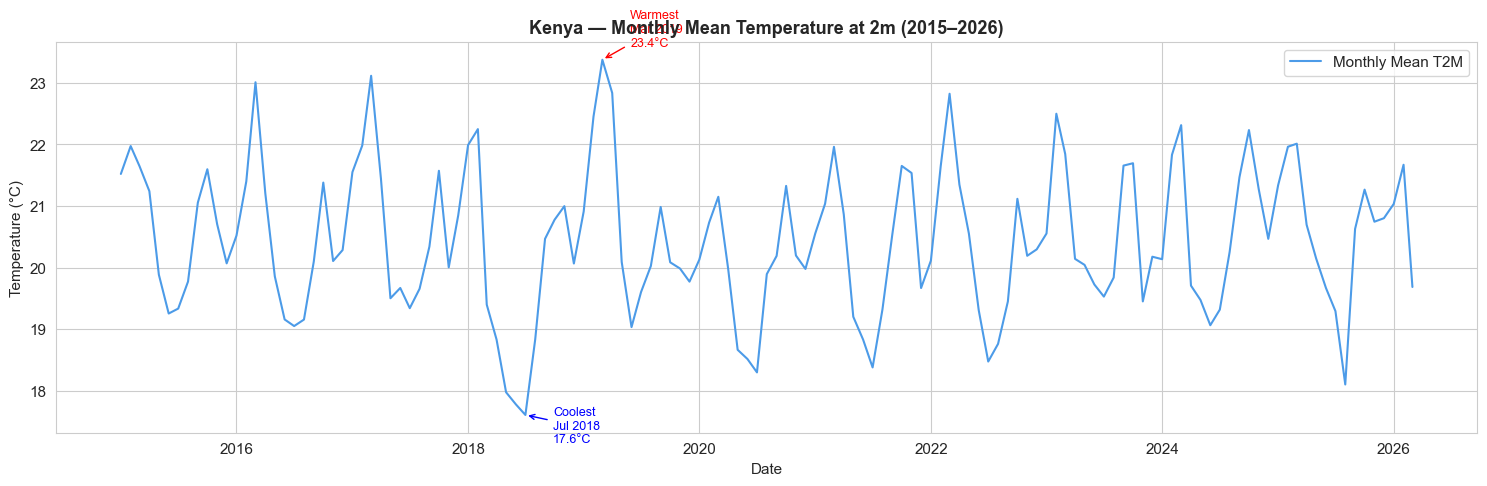

Saved temperature time series chart.


In [12]:
# Monthly average temperature over full period
monthly = df.groupby(df['Date'].dt.to_period('M')).agg(
    T2M_mean=('T2M', 'mean'),
    PREC_total=('PRECTOTCORR', 'sum')
).reset_index()
monthly['Date'] = monthly['Date'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(monthly['Date'], monthly['T2M_mean'], color='#4C9BE8', linewidth=1.5, label='Monthly Mean T2M')

# Annotate warmest and coolest months
warm_idx = monthly['T2M_mean'].idxmax()
cool_idx = monthly['T2M_mean'].idxmin()
ax.annotate(f"Warmest\n{monthly.loc[warm_idx,'Date'].strftime('%b %Y')}\n{monthly.loc[warm_idx,'T2M_mean']:.1f}°C",
            xy=(monthly.loc[warm_idx,'Date'], monthly.loc[warm_idx,'T2M_mean']),
            xytext=(20, 10), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)
ax.annotate(f"Coolest\n{monthly.loc[cool_idx,'Date'].strftime('%b %Y')}\n{monthly.loc[cool_idx,'T2M_mean']:.1f}°C",
            xy=(monthly.loc[cool_idx,'Date'], monthly.loc[cool_idx,'T2M_mean']),
            xytext=(20, -20), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='blue'), color='blue', fontsize=9)

ax.set_title('Kenya — Monthly Mean Temperature at 2m (2015–2026)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.savefig('../dashboard_screenshots/kenya_temp_timeseries.png', dpi=150)
plt.show()
print('Saved temperature time series chart.')

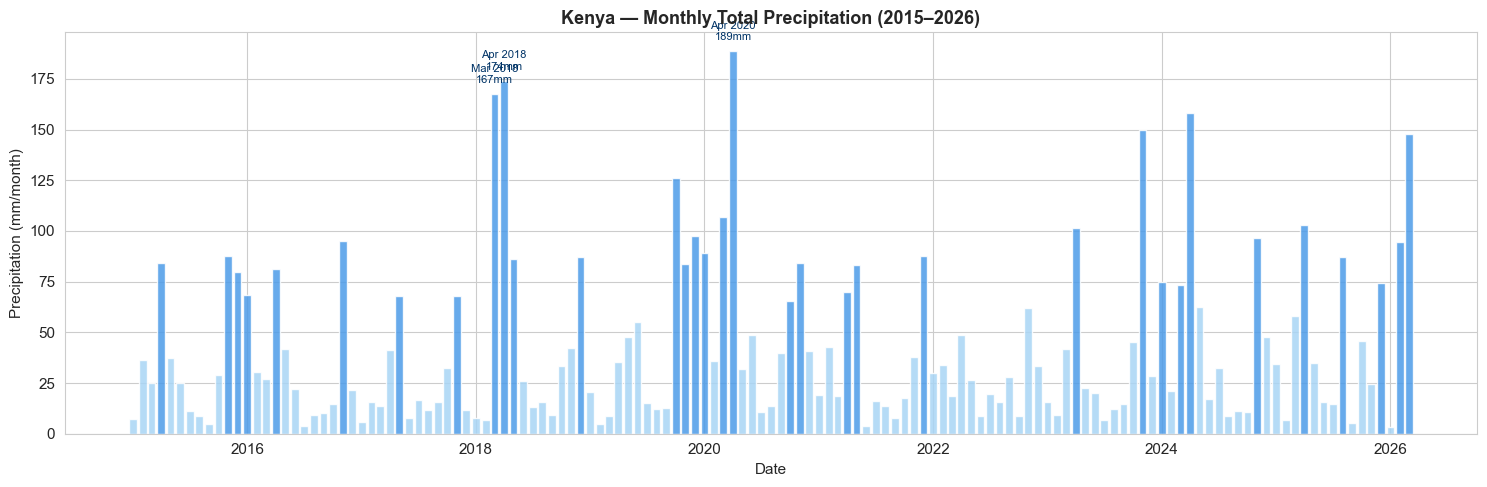

In [13]:
# Monthly total precipitation bar chart
fig, ax = plt.subplots(figsize=(15, 5))
colors = ['#4C9BE8' if v >= monthly['PREC_total'].quantile(0.75) else '#A8D5F5' for v in monthly['PREC_total']]
ax.bar(monthly['Date'], monthly['PREC_total'], color=colors, width=25, alpha=0.85)

# Annotate peak months
top3 = monthly.nlargest(3, 'PREC_total')
for _, row in top3.iterrows():
    ax.annotate(f"{row['Date'].strftime('%b %Y')}\n{row['PREC_total']:.0f}mm",
                xy=(row['Date'], row['PREC_total']),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8, color='#003366')

ax.set_title('Kenya — Monthly Total Precipitation (2015–2026)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Precipitation (mm/month)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('../dashboard_screenshots/kenya_precip_barchart.png', dpi=150)
plt.show()

In [14]:
print('\n=== KENYA EDA SUMMARY ===')
print(f'Period: {df["Date"].min().date()} to {df["Date"].max().date()}')
print(f'Total clean observations: {len(df)}')
print(f'Mean T2M: {df["T2M"].mean():.2f}°C | Max T2M_MAX: {df["T2M_MAX"].max():.2f}°C')
print(f'Total precipitation: {df["PRECTOTCORR"].sum():.0f} mm over period')
print(f'Extreme heat days (T2M_MAX > 35°C): {(df["T2M_MAX"] > 35).sum()}')
print(f'Dry days (PRECTOTCORR < 1mm): {(df["PRECTOTCORR"] < 1).sum()} ({((df["PRECTOTCORR"] < 1).mean())*100:.1f}%)')
print(f'Cleaned CSV saved to: {CLEAN_PATH}')


=== KENYA EDA SUMMARY ===
Period: 2015-01-01 to 2026-03-31
Total clean observations: 4108
Mean T2M: 20.43°C | Max T2M_MAX: 32.68°C
Total precipitation: 5700 mm over period
Extreme heat days (T2M_MAX > 35°C): 0
Dry days (PRECTOTCORR < 1mm): 2831 (68.9%)
Cleaned CSV saved to: ../data/kenya_clean.csv
